#IMPORTING

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('DM1_game_dataset_module.01 (1).csv')
print(df.shape)
print(df["Rating"].value_counts())

(21925, 42)
Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64


In [ ]:
nan_count_rating = df['Rating'].isnull().sum()
print(f"NaN in Rating: {nan_count_rating}")

NaN in Rating: 0


#GESTIONE RANK:

In [ ]:
import pandas as pd
import numpy as np
import ast

# Carico il dataset originale
df = pd.read_csv('DM1_game_dataset_module.01 (1).csv')

# 1) Identifico tutte le colonne di rank
rank_cols = [c for c in df.columns if c.startswith("Rank:")]

print("Colonne Rank individuate:", rank_cols)

# 2) Trasformo i Rank in binari: 0 se 21926 (nessun rank), 1 altrimenti
for c in rank_cols:
    df[c] = df[c].apply(lambda x: 0 if x == 21926 else 1)


Colonne Rank individuate: ['Rank:strategygames', 'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames']


#GOODPLAYERS

In [ ]:
df.drop(columns=['GoodPlayers'], inplace=True, errors='ignore')


In [ ]:
print('GoodPlayers' in df.columns)
print('GoodPlayers_avg' in df.columns)
print('GoodPlayers_min' in df.columns)
print('GoodPlayers_max' in df.columns)
print('GoodPlayers_count' in df.columns)
print('GoodPlayers_parsed' in df.columns)


False
False
False
False
False
False


#REMOVING OBJECT AND ID

In [ ]:
import pandas as pd

# (Assumo che df a questo punto abbia già:
#  - Rank binarizzati
#  - GoodPlayers_count / min / max
#  - GoodPlayers originale rimossa)

# 3.1 Rimuovo l'ID (non informativo)
df = df.drop(columns=['BGGId'], errors='ignore')

# 3.2 Controllo quali colonne NON sono numeriche (per info)
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns
print("Colonne NON numeriche (le escluderemo da X):")
print(non_numeric_cols)

# 3.3 Costruisco la matrice delle sole feature numeriche (escludo Rating se per caso è numerica)
X_num = df.select_dtypes(include=['int64', 'float64']).copy()

# Per sicurezza: se Rating è numerica per qualche motivo, la elimino da X_num
if 'Rating' in X_num.columns:
    X_num = X_num.drop(columns=['Rating'])

print("Shape X_num (solo numeriche):", X_num.shape)


Colonne NON numeriche (le escluderemo da X):
Index(['Name', 'Description', 'ImagePath', 'Rating'], dtype='object')
Shape X_num (solo numeriche): (21925, 36)


#CORRELATION MATRIK

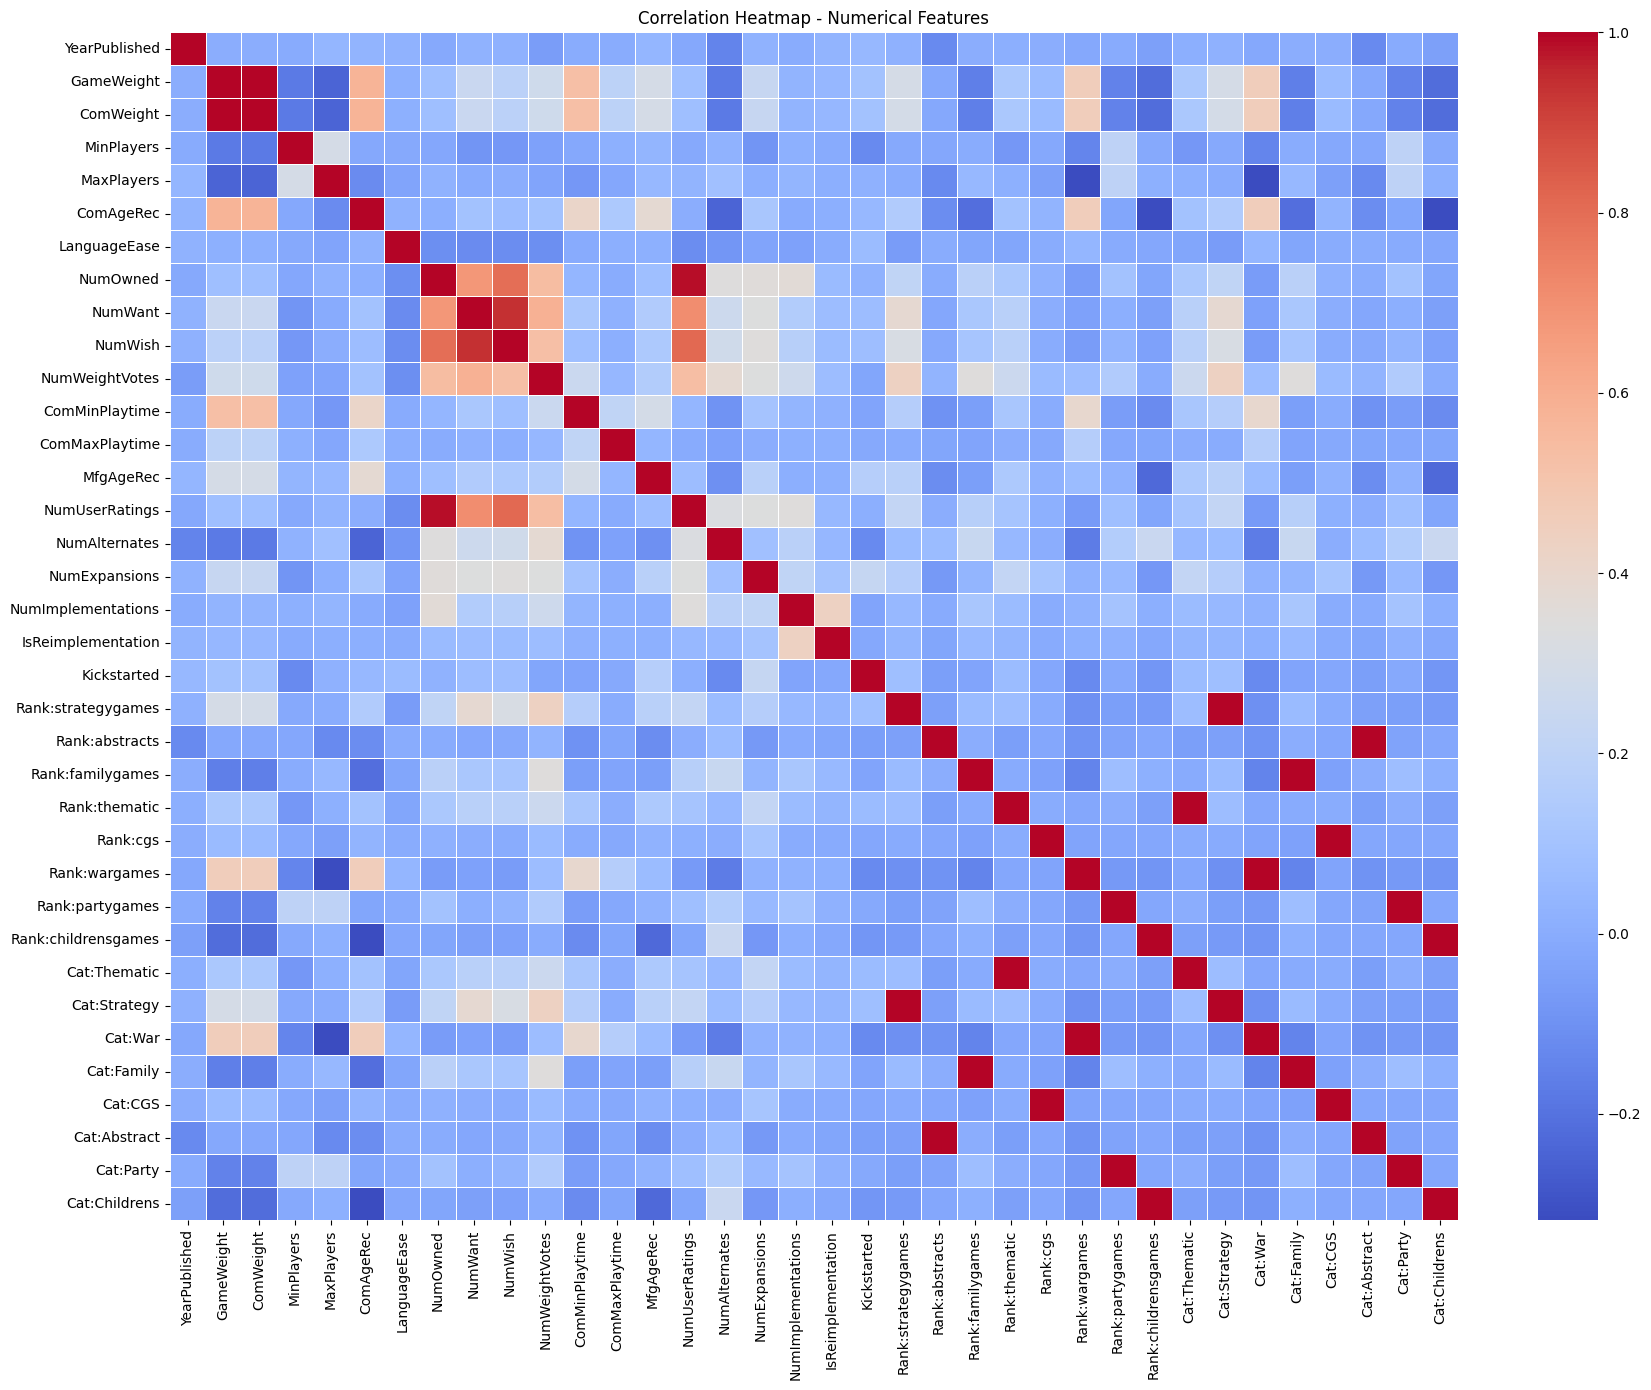

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcolo matrice di correlazione
corr_matrix = X_num.corr()

# Heatmap con i numeri, per il report
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()


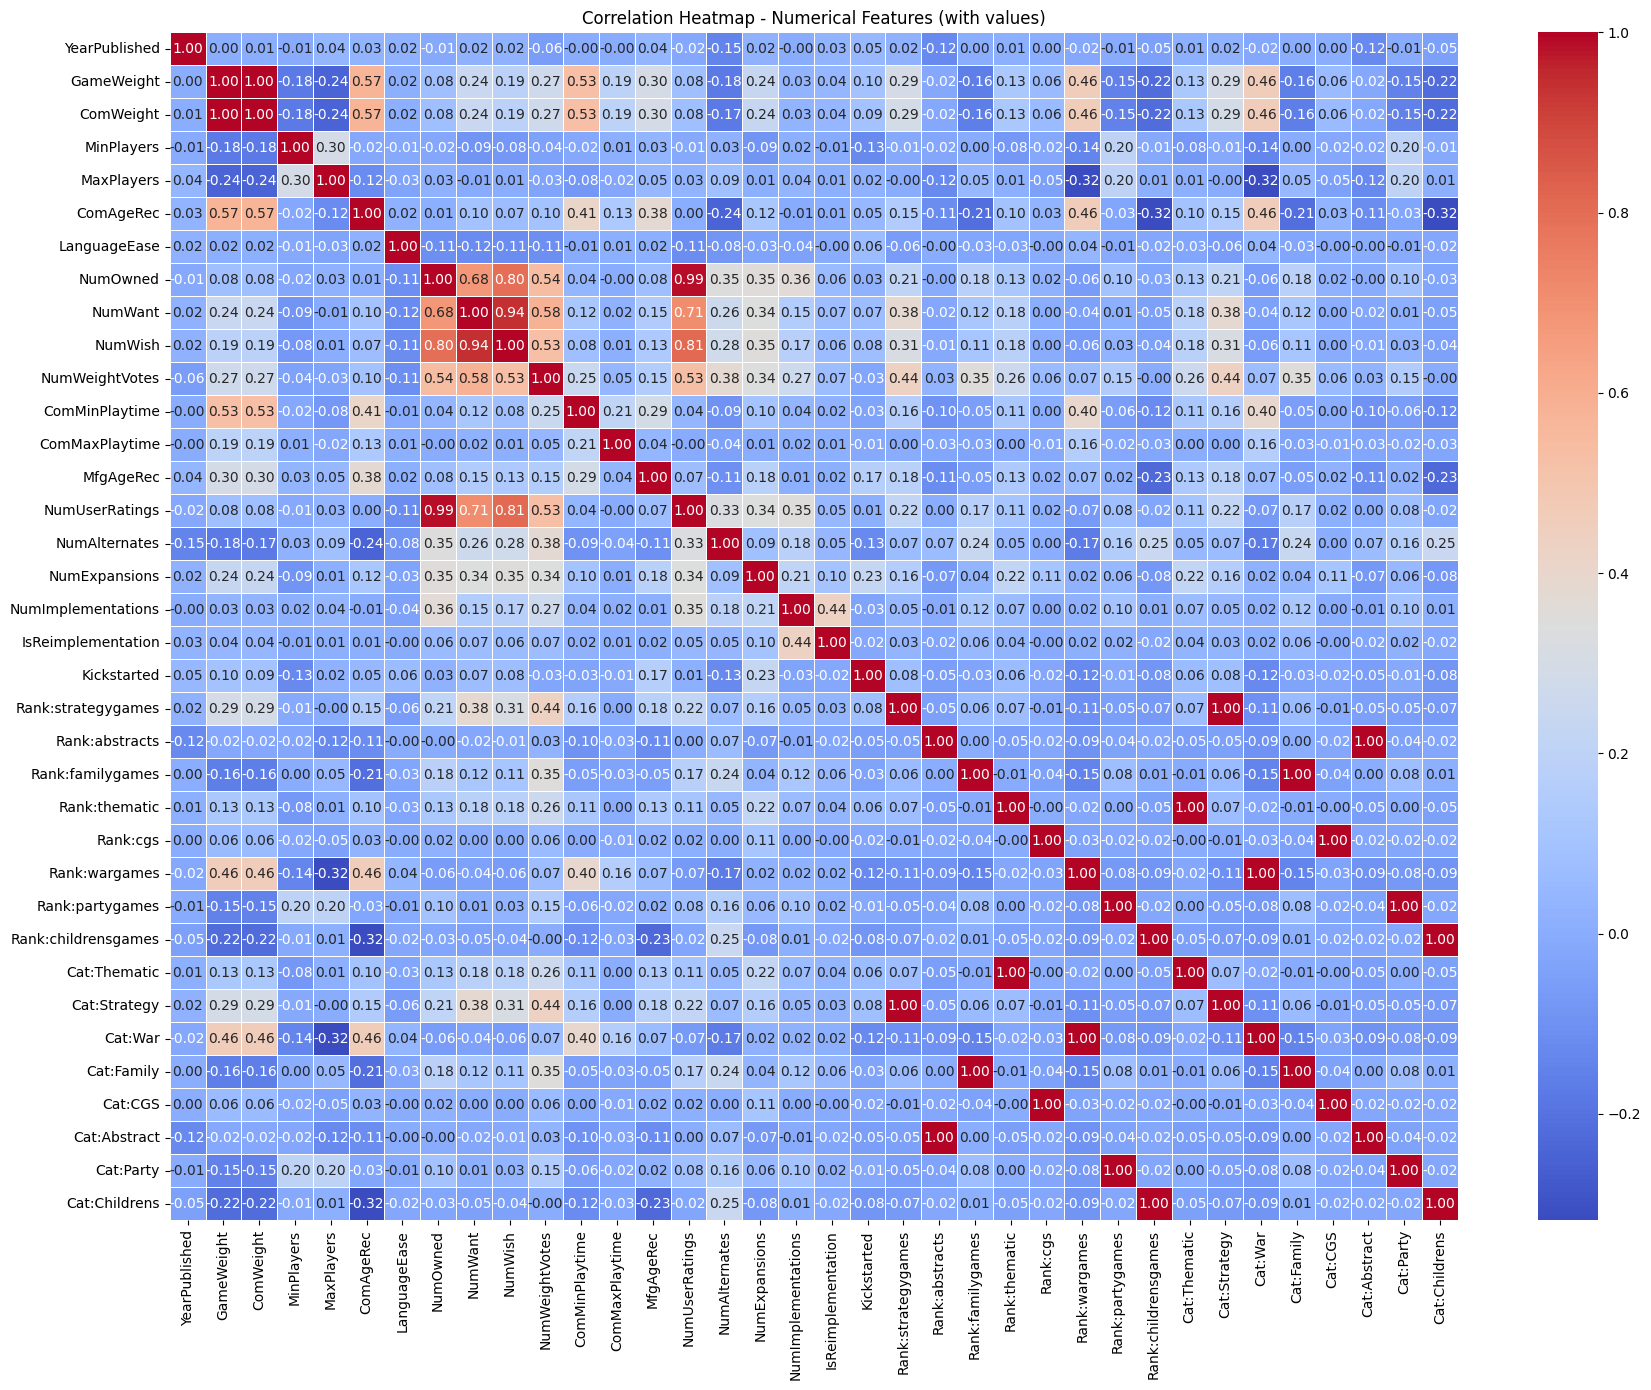

In [ ]:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap - Numerical Features (with values)")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Trasformo la matrice in una tabella lunga (feature1, feature2, corr)
corr_pairs = (
    corr_matrix
    .abs()               # usiamo il valore assoluto della correlazione
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # tengo solo triangolo superiore per evitare duplicati
    .stack()             # trasformo in serie con MultiIndex (feat1, feat2)
    .reset_index()
)

corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

# Filtro solo le coppie con correlazione > soglia
threshold = 0.55  # puoi alzare/abbassare
high_corr = corr_pairs[corr_pairs['Correlation'] > threshold].sort_values(
    by='Correlation', ascending=False
)

print("Coppie di feature con correlazione alta (> 0.80):")
print(high_corr)


Coppie di feature con correlazione alta (> 0.80):
                Feature1        Feature2  Correlation
592      Rank:partygames       Cat:Party     1.000000
601  Rank:childrensgames   Cat:Childrens     1.000000
556        Rank:thematic    Cat:Thematic     1.000000
547     Rank:familygames      Cat:Family     1.000000
579        Rank:wargames         Cat:War     1.000000
571             Rank:cgs         Cat:CGS     1.000000
536       Rank:abstracts    Cat:Abstract     1.000000
518   Rank:strategygames    Cat:Strategy     1.000000
35            GameWeight       ComWeight     0.997383
230             NumOwned  NumUserRatings     0.985474
252              NumWant         NumWish     0.939758
283              NumWish  NumUserRatings     0.814348
225             NumOwned         NumWish     0.797531
257              NumWant  NumUserRatings     0.709185
224             NumOwned         NumWant     0.677557
253              NumWant  NumWeightVotes     0.584589
38            GameWeight       C

#DROP HIGH CORRELATION FEATURE

In [ ]:
cols_to_drop_corr = ['ComWeight', 'NumUserRatings', 'NumWish']

# Drop dalle feature numeriche
X_num = X_num.drop(columns=[c for c in cols_to_drop_corr if c in X_num.columns],
                   errors='ignore')

# Drop anche dal df generale (così è coerente ovunque)
df = df.drop(columns=[c for c in cols_to_drop_corr if c in df.columns],
             errors='ignore')

print("Shape X_num dopo drop correlazione:", X_num.shape)
print("Colonne rimosse per alta correlazione:", cols_to_drop_corr)


Shape X_num dopo drop correlazione: (21925, 33)
Colonne rimosse per alta correlazione: ['ComWeight', 'NumUserRatings', 'NumWish']


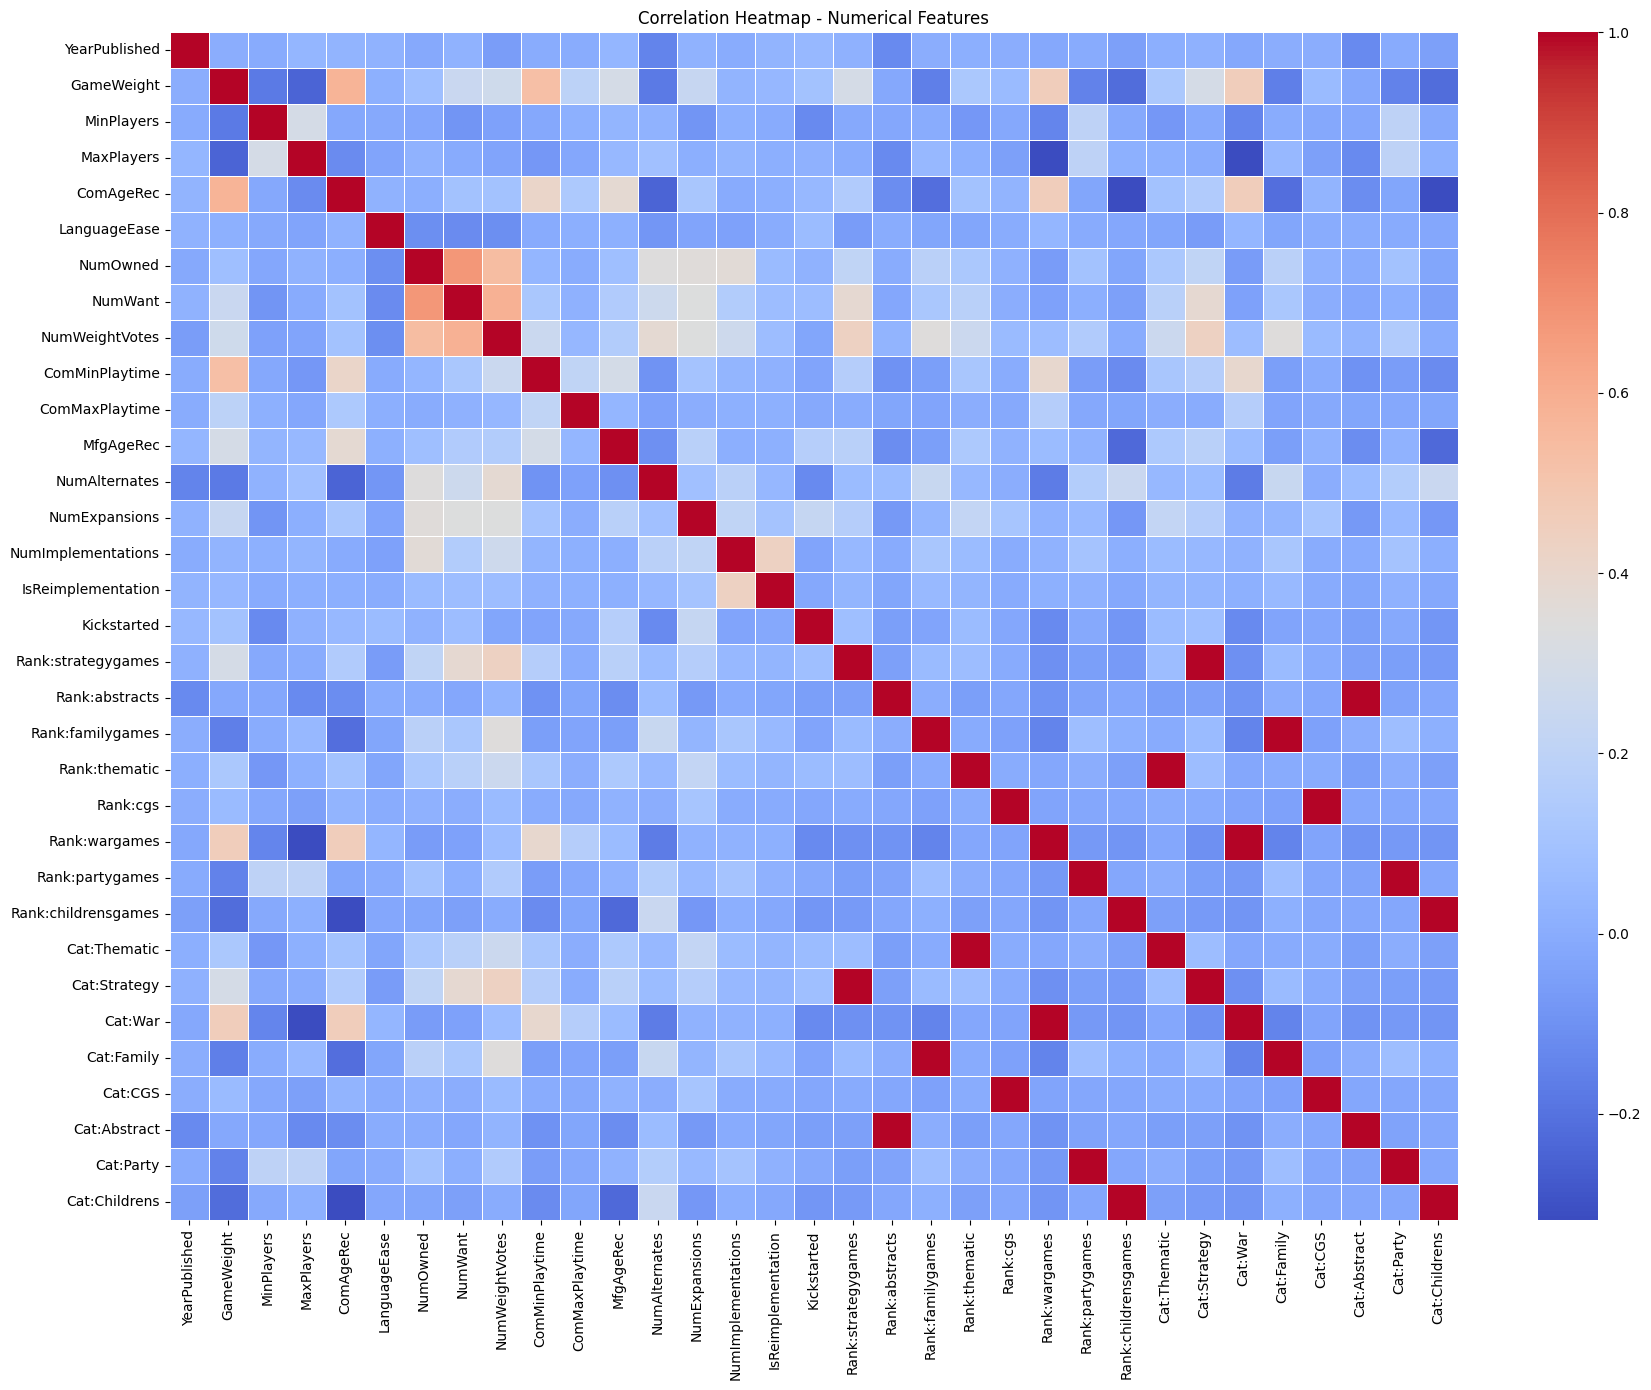

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcolo matrice di correlazione
corr_matrix = X_num.corr()

# Heatmap con i numeri, per il report
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()

#LABEL ENCODIN ON RATING

In [ ]:
print(df['Rating'].value_counts(dropna=False))
print("Num NaN in Rating:", df['Rating'].isna().sum())


Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64
Num NaN in Rating: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Target originale (stringhe)
y_raw = df['Rating']

# Encoding del target in numeri interi
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Mappatura classi Rating -> numeri:", dict(zip(le.classes_, le.transform(le.classes_))))


Mappatura classi Rating -> numeri: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


#SPLIT 60-20-20

In [ ]:
from sklearn.model_selection import train_test_split

# Prima split Train + Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_num, y,
    test_size=0.40,   # 20% val + 20% test
    random_state=42,
    stratify=y
)

# Seconda split: Temp in Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # metà di 40% → 20%
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, " | Val:", X_val.shape, " | Test:", X_test.shape)

print("\nDistribuzione classi Train:", np.bincount(y_train))
print("Distribuzione classi Val:", np.bincount(y_val))
print("Distribuzione classi Test:", np.bincount(y_test))


Train: (13155, 33)  | Val: (4385, 33)  | Test: (4385, 33)

Distribuzione classi Train: [3022 4347 5786]
Distribuzione classi Val: [1007 1449 1929]
Distribuzione classi Test: [1007 1449 1929]


#GAUSSIAN

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Modello
gnb = GaussianNB()

# Addestramento
gnb.fit(X_train, y_train)


GaussianNB()

#VALIDATION PREDICTION

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predizioni validation
y_val_pred = gnb.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy (GaussianNB):", round(val_accuracy, 4))

# Report complete su validation
print("\nVALIDATION - Classification Report")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))


Validation Accuracy (GaussianNB): 0.5334

VALIDATION - Classification Report
              precision    recall  f1-score   support

        High       0.58      0.50      0.53      1007
         Low       0.50      0.87      0.63      1449
      Medium       0.58      0.30      0.40      1929

    accuracy                           0.53      4385
   macro avg       0.55      0.56      0.52      4385
weighted avg       0.55      0.53      0.51      4385



#TEST accuracy

In [ ]:
# Predizioni test
y_test_pred = gnb.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print("TEST Accuracy (GaussianNB):", round(test_accuracy, 4))

print("\nTEST - Classification Report")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))


TEST Accuracy (GaussianNB): 0.5339

TEST - Classification Report
              precision    recall  f1-score   support

        High       0.58      0.51      0.54      1007
         Low       0.50      0.87      0.63      1449
      Medium       0.59      0.30      0.40      1929

    accuracy                           0.53      4385
   macro avg       0.56      0.56      0.52      4385
weighted avg       0.56      0.53      0.51      4385



#CONFUSION MATRIX

<Figure size 600x500 with 0 Axes>

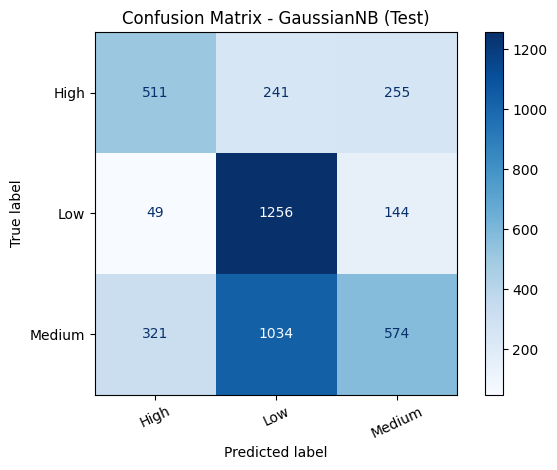

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - GaussianNB (Test)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


#ROC CURVE

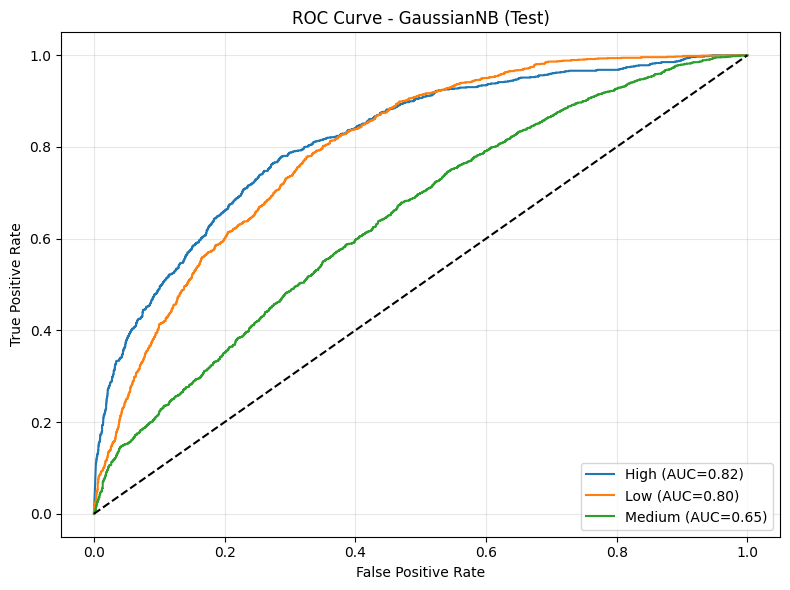

Macro AUC (GaussianNB): 0.7533


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# Binarizzo target
class_ids = np.arange(len(le.classes_))
y_test_bin = label_binarize(y_test, classes=class_ids)

# Probabilità previste dal modello
y_score = gnb.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, cl in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cl} (AUC={roc_auc:.2f})")

# baseline
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - GaussianNB (Test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Macro AUC (summary)
macro_auc = roc_auc_score(y_test_bin, y_score, average="macro")
print("Macro AUC (GaussianNB):", round(macro_auc, 4))


#RANDOM FOREST


=== FEATURE IMPORTANCE RF ===


,Feature,Importance
7,NumWant,0.151295
0,YearPublished,0.132814
1,GameWeight,0.100326
6,NumOwned,0.090743
8,NumWeightVotes,0.065056
5,LanguageEase,0.061603
10,ComMaxPlaytime,0.053152
4,ComAgeRec,0.052688
9,ComMinPlaytime,0.043793
3,MaxPlayers,0.042235



=== FEATURE SELEZIONATE ===
['NumWant', 'YearPublished', 'GameWeight', 'NumOwned', 'NumWeightVotes', 'LanguageEase', 'ComMaxPlaytime', 'ComAgeRec', 'ComMinPlaytime', 'MaxPlayers', 'MfgAgeRec', 'NumExpansions', 'NumAlternates', 'MinPlayers']

Validation Accuracy — RF + NB: 0.5339
Test Accuracy — RF + NB: 0.5391

=== CLASSIFICATION REPORT — RF Feature Selection + NB (TEST) ===
              precision    recall  f1-score   support

        High       0.70      0.33      0.45      1007
         Low       0.49      0.92      0.64      1449
      Medium       0.57      0.36      0.44      1929

    accuracy                           0.54      4385
   macro avg       0.59      0.54      0.51      4385
weighted avg       0.58      0.54      0.51      4385



<Figure size 600x500 with 0 Axes>

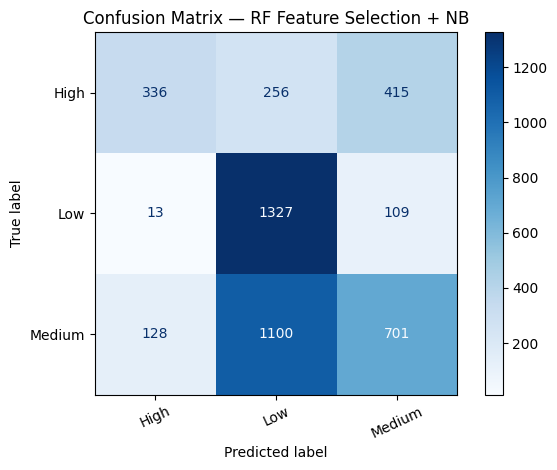

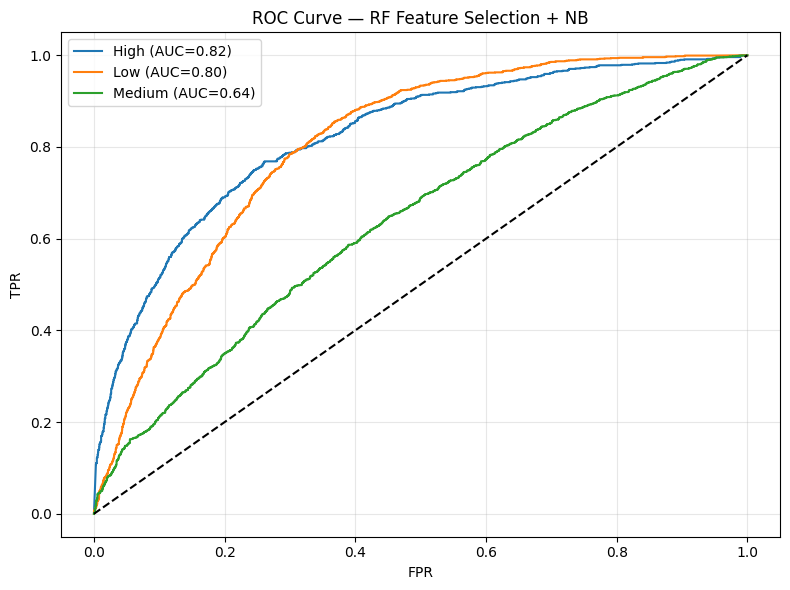


Macro AUC — RF + NB: 0.7549


In [ ]:
# ==========================================================
# MODELLO 2 — Random Forest Feature Selection + GaussianNB
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
)

# ===================================
# 1) Train Random Forest sul TRAIN
# ===================================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Importanza delle feature
feat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== FEATURE IMPORTANCE RF ===")
display(feat_importance.head(20))

# ===================================
# 2) Selezione feature con importanza >= 0.02
# ===================================
threshold = 0.02
selected_features = feat_importance[feat_importance["Importance"] >= threshold]["Feature"].tolist()

print("\n=== FEATURE SELEZIONATE ===")
print(selected_features)

# Subset dei dati
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]


# ===================================
# 3) Train GaussianNB solo con feature selezionate
# ===================================
gnb_fs = GaussianNB()
gnb_fs.fit(X_train_sel, y_train)

# VALIDATION
y_val_pred_fs = gnb_fs.predict(X_val_sel)
print("\nValidation Accuracy — RF + NB:", round(accuracy_score(y_val, y_val_pred_fs),4))

# TEST
y_test_pred_fs = gnb_fs.predict(X_test_sel)
print("Test Accuracy — RF + NB:", round(accuracy_score(y_test, y_test_pred_fs),4))

print("\n=== CLASSIFICATION REPORT — RF Feature Selection + NB (TEST) ===")
print(classification_report(y_test, y_test_pred_fs, target_names=le.classes_))


# ===================================
# 4) Confusion Matrix
# ===================================
cm = confusion_matrix(y_test, y_test_pred_fs)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    cmap="Blues", values_format='d'
)
plt.title("Confusion Matrix — RF Feature Selection + NB")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# ===================================
# 5) ROC Curve One-vs-Rest + Macro AUC
# ===================================
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_score_fs = gnb_fs.predict_proba(X_test_sel)

plt.figure(figsize=(8,6))
for i, cl in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_fs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cl} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve — RF Feature Selection + NB")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc_fs = roc_auc_score(y_test_bin, y_score_fs, average="macro")
print("\nMacro AUC — RF + NB:", round(macro_auc_fs,4))


Random Forest non è stata usata come classificatore finale, ma come strumento di selezione delle feature.

Ha svolto tre compiti fondamentali:
1. Quali sono le variabili veramente utiloi per predire il modello
2. Ha prodotto un ranking delle feature
3. Ha eliminato automaticamente le feature inutili

In [ ]:
print("\n=== FEATURE EFFETTIVAMENTE UTILIZZATE DA NB DOPO FEATURE SELECTION ===")
for f in selected_features:
    print("-", f)
print("\nTotale feature selezionate:", len(selected_features))



=== FEATURE EFFETTIVAMENTE UTILIZZATE DA NB DOPO FEATURE SELECTION ===
- NumWant
- YearPublished
- GameWeight
- NumOwned
- NumWeightVotes
- LanguageEase
- ComMaxPlaytime
- ComAgeRec
- ComMinPlaytime
- MaxPlayers
- MfgAgeRec
- NumExpansions
- NumAlternates
- MinPlayers

Totale feature selezionate: 14


#SMOTE per Medium

Distribuzione classi Train PRIMA: [3022 4347 5786]
Distribuzione classi Train DOPO : [5786 5786 5786]

Validation Accuracy (NB + SMOTE): 0.5314
Test Accuracy (NB + SMOTE): 0.54

=== CLASSIFICATION REPORT — NB + SMOTE (TEST) ===
              precision    recall  f1-score   support

        High       0.67      0.40      0.50      1007
         Low       0.49      0.92      0.64      1449
      Medium       0.59      0.33      0.42      1929

    accuracy                           0.54      4385
   macro avg       0.58      0.55      0.52      4385
weighted avg       0.58      0.54      0.51      4385



<Figure size 600x500 with 0 Axes>

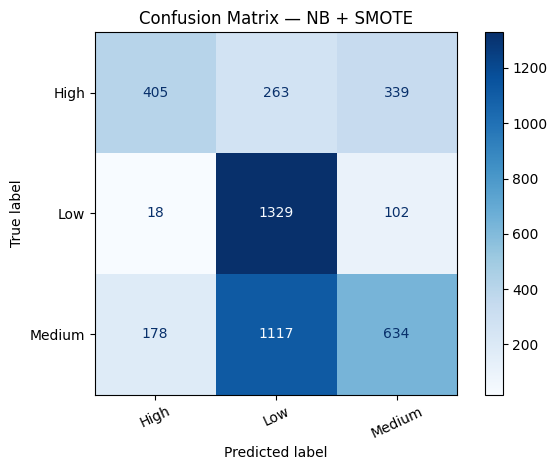

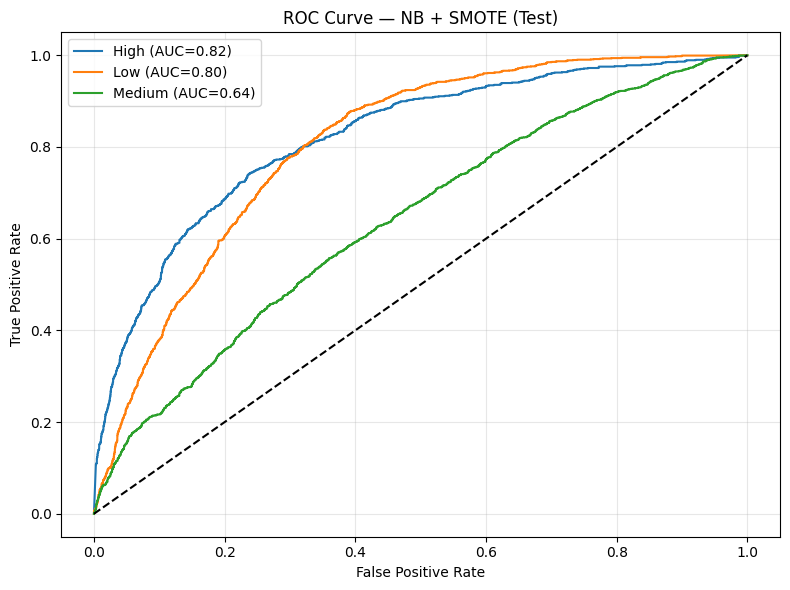


Macro AUC (NB + SMOTE): 0.7551


In [ ]:
# ==========================================================
# MODELLO 3 — SMOTE + RF Feature Selection + GaussianNB
# ==========================================================

from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
)

# ===============================
# 1. SMOTE SOLO SUL TRAIN
# ===============================
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sel, y_train)

print("Distribuzione classi Train PRIMA:", np.bincount(y_train))
print("Distribuzione classi Train DOPO :", np.bincount(y_train_sm))


# ===============================
# 2. GaussianNB con dati bilanciati
# ===============================
gnb_sm = GaussianNB()
gnb_sm.fit(X_train_sm, y_train_sm)

# VALIDATION
y_val_pred_sm = gnb_sm.predict(X_val_sel)
print("\nValidation Accuracy (NB + SMOTE):", round(accuracy_score(y_val, y_val_pred_sm),4))

# TEST
y_test_pred_sm = gnb_sm.predict(X_test_sel)
print("Test Accuracy (NB + SMOTE):", round(accuracy_score(y_test, y_test_pred_sm),4))

print("\n=== CLASSIFICATION REPORT — NB + SMOTE (TEST) ===")
print(classification_report(y_test, y_test_pred_sm, target_names=le.classes_))


# ===============================
# 3. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_test_pred_sm)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    cmap="Blues", values_format='d'
)
plt.title("Confusion Matrix — NB + SMOTE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# ===============================
# 4. ROC Curve One-vs-Rest + Macro AUC
# ===============================
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_score_sm = gnb_sm.predict_proba(X_test_sel)

plt.figure(figsize=(8,6))
for i, cl in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_sm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cl} (AUC={roc_auc:.2f})")

plt.plot([0,1],'k--')
plt.title("ROC Curve — NB + SMOTE (Test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc_sm = roc_auc_score(y_test_bin, y_score_sm, average="macro")
print("\nMacro AUC (NB + SMOTE):", round(macro_auc_sm, 4))


#PCA

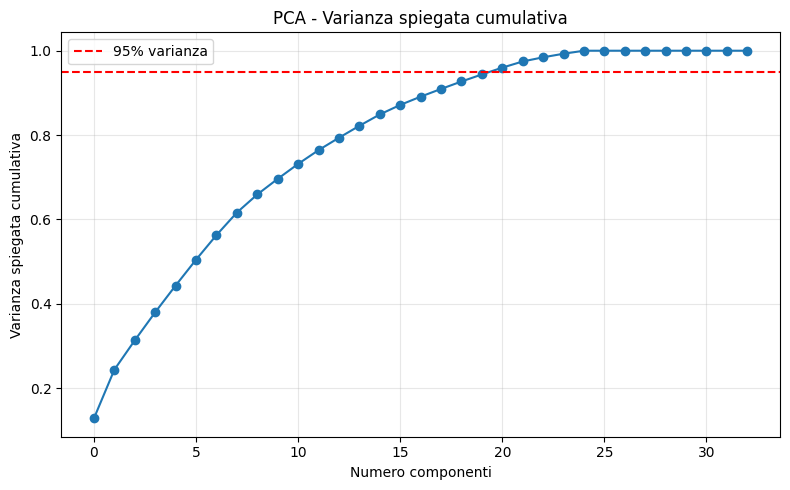

Numero componenti PCA per >=95% varianza: 21
Shape X_train_pca: (13155, 21)

Validation Accuracy (NB + PCA): 0.5526
Test Accuracy (NB + PCA): 0.5318

=== CLASSIFICATION REPORT — NB + PCA (TEST) ===
              precision    recall  f1-score   support

        High       0.57      0.40      0.47      1007
         Low       0.52      0.61      0.56      1449
      Medium       0.53      0.54      0.53      1929

    accuracy                           0.53      4385
   macro avg       0.54      0.52      0.52      4385
weighted avg       0.53      0.53      0.53      4385



<Figure size 600x500 with 0 Axes>

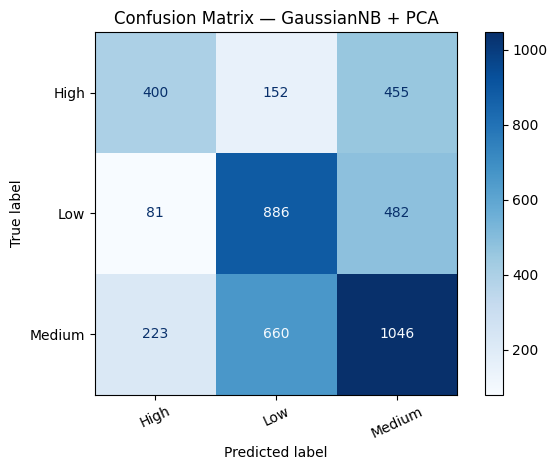

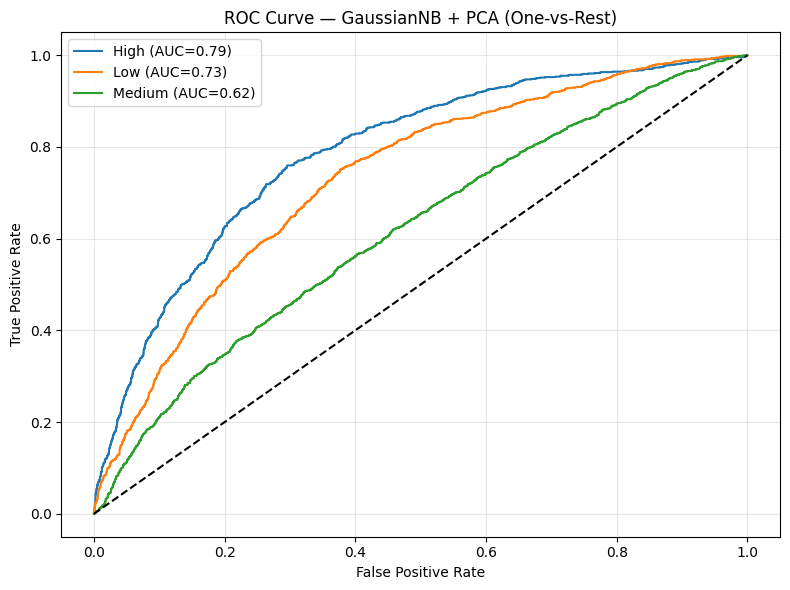


Macro AUC (NB + PCA): 0.7123


In [ ]:
# ==========================================================
# MODELLO 4 — PCA + Gaussian Naive Bayes
# (usiamo X_train, X_val, X_test, y_train, y_val, y_test della baseline)
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Standardizzazione delle feature
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ===============================
# 2. PCA - Varianza spiegata
# ===============================
pca = PCA()
pca.fit(X_train_scaled)

explained_var_cum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_var_cum, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.title("PCA - Varianza spiegata cumulativa")
plt.xlabel("Numero componenti")
plt.ylabel("Varianza spiegata cumulativa")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Numero componenti per raggiungere almeno il 95% di varianza
n_components_95 = np.argmax(explained_var_cum >= 0.95) + 1
print("Numero componenti PCA per >=95% varianza:", n_components_95)

# PCA definitivo con n_components_95
pca_95 = PCA(n_components=n_components_95)
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_val_pca   = pca_95.transform(X_val_scaled)
X_test_pca  = pca_95.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)


# ===============================
# 3. GaussianNB sui componenti principali
# ===============================
gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)

# VALIDATION
y_val_pred_pca = gnb_pca.predict(X_val_pca)
val_acc_pca = accuracy_score(y_val, y_val_pred_pca)
print("\nValidation Accuracy (NB + PCA):", round(val_acc_pca, 4))

# TEST
y_test_pred_pca = gnb_pca.predict(X_test_pca)
test_acc_pca = accuracy_score(y_test, y_test_pred_pca)
print("Test Accuracy (NB + PCA):", round(test_acc_pca, 4))

print("\n=== CLASSIFICATION REPORT — NB + PCA (TEST) ===")
print(classification_report(y_test, y_test_pred_pca, target_names=le.classes_))


# ===============================
# 4. Confusion Matrix
# ===============================
cm_pca = confusion_matrix(y_test, y_test_pred_pca)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — GaussianNB + PCA")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# ===============================
# 5. ROC One-vs-Rest + Macro AUC
# ===============================
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_score_pca = gnb_pca.predict_proba(X_test_pca)

plt.figure(figsize=(8,6))
for i, cl in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_pca[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cl} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1], 'k--')
plt.title("ROC Curve — GaussianNB + PCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc_pca = roc_auc_score(y_test_bin, y_score_pca, average="macro")
print("\nMacro AUC (NB + PCA):", round(macro_auc_pca, 4))
